In [1]:
import pandas, numpy, scipy

In [2]:
import sklearn, sklearn.preprocessing, sklearn.decomposition

In [3]:
import matplotlib, matplotlib.pyplot
matplotlib.rcParams.update({'font.size':20, 
                            'font.family':'sans-serif', 
                            'xtick.labelsize':16, 
                            'ytick.labelsize':16, 
                            'figure.figsize':(16*(2/3), 9*(2/3)), 
                            'axes.labelsize':20
                           })

# 0. user-defined variables

In [4]:
input_file = '/Users/adrian/research/bmcbf/054_selfoss/results/DESeq2_TPM_values.tsv'

# 1. read expression

In [5]:
expression = pandas.read_csv(input_file, sep='\t', index_col=0)
print(expression.shape)
expression

(39546, 6)


,R20.24-1,R20.24-2,R20.24-3,RPCI-WM1-1,RPCI-WM1-2,RPCI-WM1-3
ENSG00000000003.15,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000000005.6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000000419.14,135.795369,84.528767,91.582486,47.239012,61.688477,61.098291
ENSG00000000457.14,12.054985,7.540398,9.180822,4.845606,4.392941,4.153611
ENSG00000000460.17,13.284788,12.375551,11.839115,12.851050,14.001322,10.808944
...,...,...,...,...,...,...
ENSG00000291297.1,0.110111,0.103091,0.412546,0.000000,0.000000,0.000000
ENSG00000291298.1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000291299.1,0.393752,1.062167,1.485241,0.583935,1.308604,1.111295
ENSG00000291300.1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [6]:
for element in expression.columns:
    print(element)

R20.24-1
R20.24-2
R20.24-3
RPCI-WM1-1
RPCI-WM1-2
RPCI-WM1-3


# 3. filter and transform

In [7]:
substantial_expression = expression[expression.max(axis=1) >= 2]
high_expression = expression[expression.max(axis=1) >= 100]

print(substantial_expression.shape)
print(high_expression.shape)

(11807, 6)
(1561, 6)


In [8]:
transpose = substantial_expression.transpose()
pca_substantial_expression = numpy.log2(transpose + 1)

transpose = high_expression.transpose()
pca_high_expression = numpy.log2(transpose + 1)

# 4. visualize substantial expression

In [9]:
scaled_data = sklearn.preprocessing.StandardScaler().fit_transform(pca_substantial_expression)
model = sklearn.decomposition.PCA(n_components=2)
new = model.fit_transform(scaled_data)
explained = model.explained_variance_ratio_
print(explained)

[0.51724065 0.2711933 ]


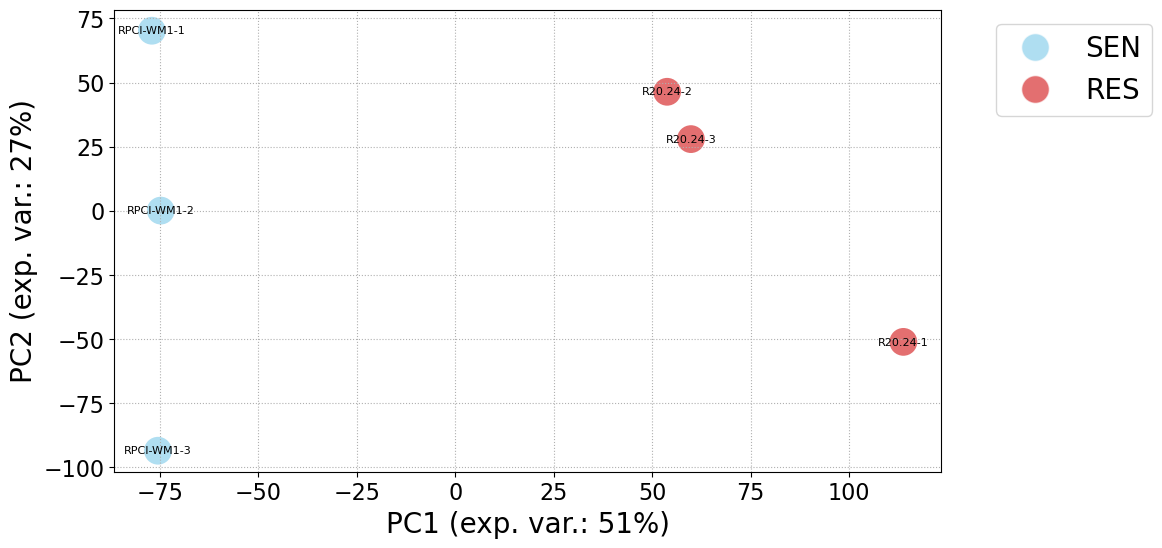

In [10]:
for i in range(len(new)):

    # colors
    name = expression.columns[i]
    
    if 'WM' in name:
        the_color = 'skyblue'
    else:
        the_color = 'tab:red'
        
    matplotlib.pyplot.scatter(new[i,0], new[i,1], s=400, c=the_color, marker='o', alpha=2/3, edgecolors='none')
    epsilon = 0
    matplotlib.pyplot.text(new[i,0]+epsilon, new[i,1]+epsilon, name, size=8, va='center', ha='center')

legend_elements = [
    
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='skyblue', markeredgecolor='white', markersize=20, alpha=2/3),
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='tab:red', markeredgecolor='white', markersize=20, alpha=2/3),
    
]

matplotlib.pyplot.legend(legend_elements, ['SEN', 'RES'], ncol=1, loc='upper left', bbox_to_anchor=(1.05, 1))
    
matplotlib.pyplot.xlabel('PC1 (exp. var.: {}%)'.format(int(explained[0]*100)))
matplotlib.pyplot.ylabel('PC2 (exp. var.: {}%)'.format(int(explained[1]*100)))
matplotlib.pyplot.grid(ls=':')

matplotlib.pyplot.show()
#matplotlib.pyplot.savefig('pca.svg')

# 4. visualize high expression

In [11]:
scaled_data = sklearn.preprocessing.StandardScaler().fit_transform(pca_high_expression)
model = sklearn.decomposition.PCA(n_components=2)
new = model.fit_transform(scaled_data)
explained = model.explained_variance_ratio_
print(explained)

[0.50756064 0.32316058]


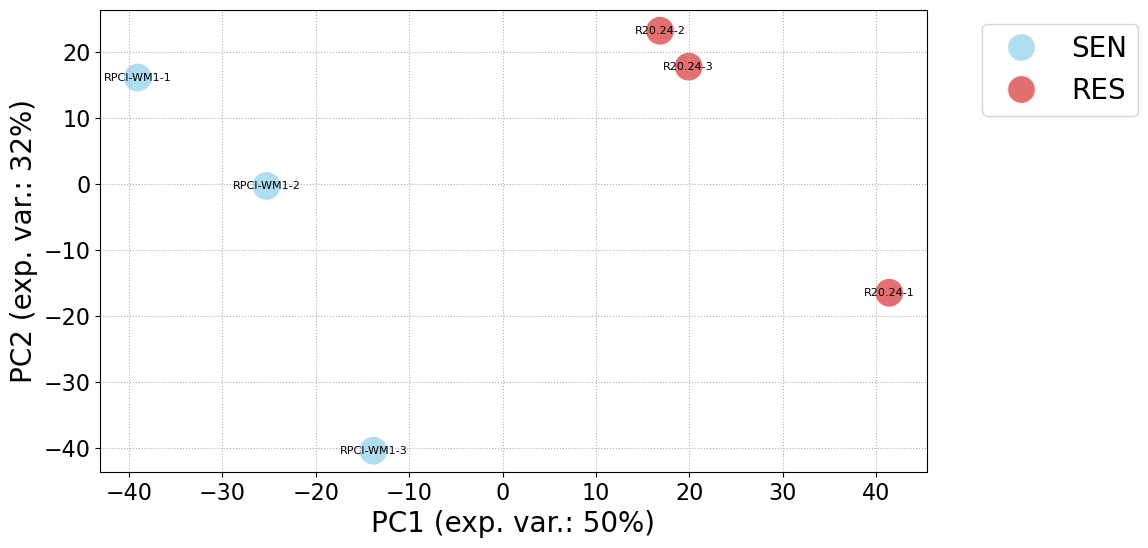

In [12]:
for i in range(len(new)):

    # colors
    name = expression.columns[i]
    
    if 'WM' in name:
        the_color = 'skyblue'
    else:
        the_color = 'tab:red'
    
    matplotlib.pyplot.scatter(new[i,0], new[i,1], s=400, c=the_color, marker='o', alpha=2/3, edgecolors='none')
    epsilon = 0
    matplotlib.pyplot.text(new[i,0]+epsilon, new[i,1]+epsilon, name, size=8, va='center', ha='center')

legend_elements = [
    
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='skyblue', markeredgecolor='white', markersize=20, alpha=2/3),
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='tab:red', markeredgecolor='white', markersize=20, alpha=2/3),
    
]

matplotlib.pyplot.legend(legend_elements, ['SEN', 'RES'], ncol=1, loc='upper left', bbox_to_anchor=(1.05, 1))
    
matplotlib.pyplot.xlabel('PC1 (exp. var.: {}%)'.format(int(explained[0]*100)))
matplotlib.pyplot.ylabel('PC2 (exp. var.: {}%)'.format(int(explained[1]*100)))
matplotlib.pyplot.grid(ls=':')

matplotlib.pyplot.show()
#matplotlib.pyplot.savefig('pca.svg')

In [13]:
# 5. distributions

In [14]:
log2_tpm_PO = numpy.log2(expression + 1)
log2_tpm_PO.head()

,R20.24-1,R20.24-2,R20.24-3,RPCI-WM1-1,RPCI-WM1-2,RPCI-WM1-3
ENSG00000000003.15,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000000005.6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000000419.14,7.095876,6.418338,6.532667,5.592128,5.970128,5.956482
ENSG00000000457.14,3.706529,3.094303,3.347782,2.547353,2.431072,2.365584
ENSG00000000460.17,3.836408,3.741526,3.682474,3.791923,3.907018,3.561808


162
16.1544683706889


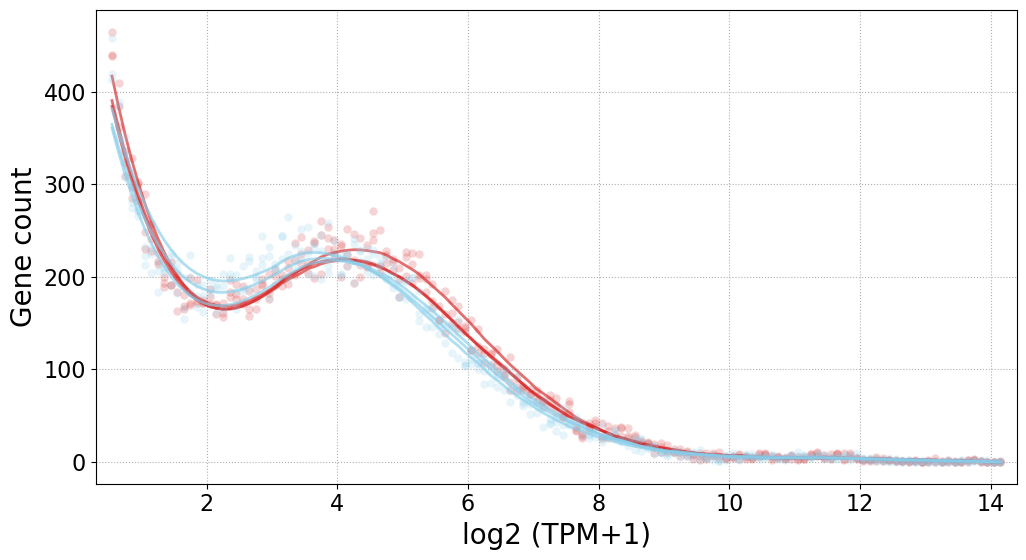

In [15]:
found_max = 16.2
number_of_bins = int(found_max*10)
print(number_of_bins)

absolute_max = 0
working_samples = log2_tpm_PO.columns.to_list()

most_likely_expressions = []
all_hats = []
for i in range(len(working_samples)):

    name = working_samples[i]

    if 'WM' in name:
        the_color = 'skyblue'
    else:
        the_color = 'tab:red'
    
    log2TPM = log2_tpm_PO.loc[:, name]
    if max(log2TPM) > absolute_max:
        absolute_max = max(log2TPM)
                
    hist, bin_edges = numpy.histogram(log2TPM, bins=number_of_bins, range=(0, found_max))
    half_bin = (bin_edges[1] - bin_edges[0])/2
    x = bin_edges + half_bin
    x = x[:-1]
  
    plotting_x = x[5:-20]
    plotting_hist = hist[5:-20]
    #print(plotting_x)
    
    matplotlib.pyplot.plot(plotting_x, plotting_hist, 'o', alpha=1/5, mec='none', color=the_color)
    yhat = scipy.signal.savgol_filter(plotting_hist, 51, 3)

    matplotlib.pyplot.plot(plotting_x, yhat, '-', lw=2, alpha=2/3, color=the_color)
    
matplotlib.pyplot.xlim([numpy.min(plotting_x)-0.25, numpy.max(plotting_x)+0.25])
#matplotlib.pyplot.ylim([0, 400])

matplotlib.pyplot.xlabel('log2 (TPM+1)')
matplotlib.pyplot.ylabel('Gene count')
matplotlib.pyplot.grid(ls=':')

matplotlib.pyplot.tight_layout()

print(absolute_max)